First, import the network generation and analysis modules.

In [1]:
# include file where structure analysis modules are stored
include("structure_analysis_modules.jl")

# import my module that contains all functions for the generation and analysis of networks
import .NetworkGeneration as NG
import .NetworkAnalysis as NA
import .GeneralUtilities as GU

import Plots

# Network generation
## Basics
We start by generating a MetaGraph object which will contain all the information about our spatial network. The initial network is periodic and can be a diamond, primitive cubic, BCC and FCC network (more precisely, this should say dia, pcu, bcu and fcu).

In [2]:
evolution_dict = NA.get_evolution_dict(;nr_vertices = 216, network_type="diamond", bond_bending_const=0.285, min_ring_size=3)
spatial_network = NG.get_periodic_network(evolution_dict)

Meta graph based on a Graphs.SimpleGraphs.SimpleGraph{Int64} with vertex labels of type Int64, vertex metadata of type Dict{String, Vector{Float64}}, edge metadata of type Dict{String, Union{Float64, Vector{Float64}}}, graph metadata given by Dict{String, Any}("bond_bending_const" => 0.285, "total_energy_up_to_date" => true, "supercell_edge_length" => 6.9282032302755105, "coordination_nr" => 4, "nr_dimensions" => 3, "nr_vertices" => 216, "total_energy" => 8.399622014737209e-29), and default weight 1.0

We can visualize the initial network (this will open in a new window).

In [3]:
NG.plot_spatial_network(spatial_network)

The network has some general properties which are stored as a dictionary and can be accessed as follows.

In [4]:
spatial_network[]

Dict{String, Any} with 7 entries:
  "bond_bending_const"      => 0.285
  "total_energy_up_to_date" => true
  "supercell_edge_length"   => 6.9282
  "coordination_nr"         => 4
  "nr_dimensions"           => 3
  "nr_vertices"             => 216
  "total_energy"            => 8.39962e-29

Furthermore, information about its vertices (or nodes) and bonds (or edges) can be accessed in the following way.

In [5]:
import MetaGraphsNext
println(spatial_network[1])
println(collect(MetaGraphsNext.neighbor_labels(spatial_network, 1)))
println(spatial_network[1,24])

Dict("position" => [0.2886751345948129, 0.2886751345948129, 0.2886751345948129])
[24, 55, 150, 213]
Dict{String, Union{Float64, Vector{Float64}}}("vector" => [0.577350269189626, 0.577350269189626, -0.5773502691896262], "distance_squared" => 1.0000000000000009)


For more details, consider the documentation of the `MetaGraphsNext` package: https://juliagraphs.org/MetaGraphsNext.jl/stable/

Now, we can perform one Monte Carlo move which consists of switching a bond and relaxing the network. The temperature parameter controls, how likely a bond switch is to be accepted. At $T=0$, only a decrease in total Keating energy is allowed. Since we start from the ground state, this is not possible initially. We choose a high temperature which favors an increase in energy to be allowed. A note on the Keating energy and units. The Keating energy is defined in 10.1103/PhysRev.145.637 and further explained in 10.1103/PhysRevB.62.4985. All energies will be given in units of $\alpha d^2$ where $\alpha$ is the bond-stretching force constant and $d$ is the ground state bond length. Temperatures are given in units of $\alpha d^2/k_\mathrm{B}$ where $k_\mathrm{B}$ is the Boltzmann constant.

In [6]:
temperature = 10

spatial_network, move_accepted = NG.monte_carlo_move!(
    spatial_network, 
    evolution_dict,
    temperature)

println("Move accepted: ", move_accepted)
NG.plot_spatial_network(spatial_network)

Move accepted: true


We can evolve the network for a given number of Monte Carlo moves (that is attempted bond switches).

Attempt chain (93, 76, 79, 99)
Chain (93, 76, 79, 99) accepted. Energy: 0.8789336586914274
Attempt chain (40, 34, 182, 179)
Chain (40, 34, 182, 179) accepted. Energy: 1.4843918944769823
Attempt chain (68, 71, 17, 166)
Chain (68, 71, 17, 166) accepted. Energy: 1.7465413600113349
Attempt chain (37, 59, 64, 65)
Chain (37, 59, 64, 65) accepted. Energy: 2.3020933662204475
Attempt chain (148, 151, 171, 174)
Chain (148, 151, 171, 174) accepted. Energy: 2.8959139987542
Attempt chain (182, 34, 181, 203)
Chain (182, 34, 181, 203) accepted. Energy: 3.2273191158286156
Attempt chain (134, 202, 208, 203)
Chain (134, 202, 208, 203) accepted. Energy: 3.985014038962902
Attempt chain (126, 194, 199, 147)
Chain (126, 194, 199, 147) accepted. Energy: 4.248455074310899
Attempt chain (111, 131, 134, 201)
Chain (111, 131, 134, 201) accepted. Energy: 4.970479904208964
Attempt chain (19, 22, 90, 21)
Chain (19, 22, 90, 21) accepted. Energy: 5.605840255233005


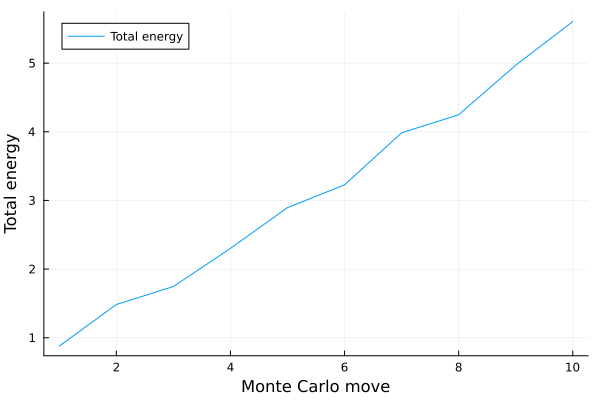

In [7]:
nr_attempted_bond_switches = 10

spatial_network, total_energy_vec, move_accepted_vec = NG.evolve_network!(
    spatial_network,
    evolution_dict,
    nr_attempted_bond_switches, 
    temperature;
    print_progress = true,
    print_every_nr_attempted_bond_switches = 1)

Plots.plot(total_energy_vec, xlabel="Monte Carlo move", ylabel="Total energy", label="Total energy")

Let's visualize the network again.

In [8]:
NG.plot_spatial_network(spatial_network)

Usually, we want to set a temperature sequence to heat and/or cool the network. After the heating and cooling and nonzero temperature, we typically quench the network. That is we evolve the network at $T=0$ until no single bond switch can reduce the total energy any more. Note that one Monte Carlo step is defined as the number of Monte Carlo moves where on average, every bond chain was attempted once. For a network with $N$ vertices, in 10.1103/PhysRevB.62.4985, they state: 'A combination of four atoms ABCD with bonds AB, BC, and CD can be selected in $N \cdot 4 \cdot 3 \cdot 3/2$ times, so there are 18N possible bond transpositions.'. If we want to increase the temperature very quickly, we set the gradient to $T/N_\mathrm{MC}=10 \alpha d^2/k_\mathrm{B}$. The argument `nr_monte_carlo_steps_per_temperature` sets the resolution how finely the temperature should be increased. A default value of $0.01$ typically works well.

In [9]:
maximal_temperature = 0.1,

temperature_vec, nr_monte_carlo_steps_per_temperature_vec = NA.get_temperature_sequence_heating_cooling_gradient(maximal_temperature;
            temperature_increase_per_monte_carlo_step = 10.0, 
            nr_monte_carlo_steps_per_temperature = 2/3888,
            quench = false )

length(temperature_vec)

ErrorException: syntax: invalid assignment location "0.1" around c:\Users\HemmannF\OneDrive - Université de Fribourg\structure_analysis\code_photonic_structures\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X24sZmlsZQ==.jl:1

In [10]:
evolution_dict["temperature_vec"] = temperature_vec
evolution_dict["nr_monte_carlo_steps_per_temperature_vec"] = nr_monte_carlo_steps_per_temperature_vec

spatial_network, total_energy_vec, move_accepted_vec = NG.evolve_network_temperature_sequence!(
    spatial_network,
    evolution_dict;
    total_energy_vec = total_energy_vec,
    move_accepted_vec= move_accepted_vec,
    print_progress = true,
    print_every_nr_attempted_bond_switches = 10)

UndefVarError: UndefVarError: `temperature_vec` not defined

Let us save the generated network to a GML file which can, for example, be loaded by Python's `Networkx` package.

In [11]:
save_path = raw".\my_networks\\"
filename = "example_network"

NG.save_spatial_network_to_gml(
    spatial_network,
    filename;
    evolution_dict = evolution_dict,
    save_path = save_path)

Loading the network and the evolution dictionary works as follows.

In [12]:
spatial_network = NG.load_spatial_network_from_gml(save_path*filename*".gml")
evolution_dict = GU.load_h5_dict(save_path*filename*"_evolution.h5")

Dict{String, Any} with 20 entries:
  "bond_bending_const"                       => 0.285
  "nr_max_relaxation_cycles"                 => 25
  "nr_monte_carlo_steps_per_temperature_vec" => [10, 10]
  "temperature_vec"                          => [2, 1]
  "inefficient_optimization_method"          => "newton"
  "estimated_nr_bond_switches"               => 77760
  "nr_vertices"                              => 216
  "reject_during_relaxation_cycle_threshold" => 5
  "thermal_fluctuations"                     => false
  "min_ring_size"                            => 3
  "mean_nr_monte_carlo_steps_for_quenching"  => 13.7
  "shell_nr"                                 => 4
  "relax_efficiently"                        => true
  "break_at_relative_cluster_energy_change"  => 0.0001
  "nr_dimensions"                            => 3
  "network_type"                             => "diamond"
  "relaxation_optimization_parameter_l"      => 1
  "relaxation_overshoot_factor_r"            => 1.5
  "relax_g

The vertices and bonds in the spatial network are connected using periodic boundary conditions. If we want to plot the network or run an optical simulation with it, we need to transform the network by adding virtual vertices outside the supercell and connecting the vertices close to the cell edges to those virtual vertices. Furthermore, if a bond sits close to the edge and we want to assign a cylinder to it, we need to duplicate the bond on the other site of the supercell just outside of the simulation box. These actions can be performed using the following function.

In [13]:
spatial_network = NG.get_spatial_network_for_simulation(
    spatial_network;
    vector_out_of_supercell_length = 1,
    duplicate_bonds_close_to_supercell_edge = true,
    bond_radius = 0.35,
    save_result = true,
    filename = filename,
    save_path = save_path)

Meta graph based on a Graphs.SimpleGraphs.SimpleGraph{Int64} with vertex labels of type Int64, vertex metadata of type Dict{String, Any}, edge metadata of type Dict{String, Any}, graph metadata given by Dict{String, Any}("bond_bending_const" => 0.285, "total_energy_up_to_date" => true, "supercell_edge_length" => 6.9282032302755105, "coordination_nr" => 4, "nr_dimensions" => 3, "nr_vertices" => 666, "total_energy" => 5.605840255233005), and default weight 1.0

In [14]:
spatial_network[]

Dict{String, Any} with 7 entries:
  "bond_bending_const"      => 0.285
  "total_energy_up_to_date" => true
  "supercell_edge_length"   => 6.9282
  "coordination_nr"         => 4
  "nr_dimensions"           => 3
  "nr_vertices"             => 666
  "total_energy"            => 5.60584

In case, we want to export a given network as a file that can be handled by Blender or another rendering software, we can create cylinder meshes for all bonds. For this we need to set a radius which is passed in units of the equilibrium bond length $d$.

In [15]:
save_path = raw".\my_networks\geometrical_models\\"
filename = "example_network"

NG.save_mesh_from_spatial_network(
    spatial_network, 
    filename;
    bond_radius = 0.35,
    vector_out_of_supercell_length = 1,
    save_path = save_path,
    duplicate_bonds_close_to_supercell_edge = true,
    format = "obj")

## Parallel network generation

There are two functions implemented to generate networks in parallel on multiple threads. For this, we first need to generate the evolution dictionaries of multiple networks and save them locally.

In [16]:
maximal_temperatures = [0.11, 0.12]
temperature_increase_per_monte_carlo_step = 0.1
nr_vertices = 216
bond_bending_const = 0.285
evolution_dicts_directory_path = raw".\my_networks\my_evolution_dicts\\"

for maximal_temperature in maximal_temperatures
    temperature_vec, nr_monte_carlo_steps_per_temperature_vec = NA.get_temperature_sequence_heating_cooling_gradient(maximal_temperature;
            temperature_increase_per_monte_carlo_step = 10.0, 
            nr_monte_carlo_steps_per_temperature = 2/3888,
            quench = false )
    evolution_dict = NA.get_evolution_dict(;nr_vertices = nr_vertices ,temperature_vec = temperature_vec,
        nr_monte_carlo_steps_per_temperature_vec = nr_monte_carlo_steps_per_temperature_vec, min_ring_size = 3,
        bond_bending_const = bond_bending_const)
    filename = string(nr_vertices)*"_vertices_T_"*string(maximal_temperature)*"_heat_cool_"*string(temperature_increase_per_monte_carlo_step)*"_per_mc"
    GU.save_dict_to_h5(evolution_dict, evolution_dicts_directory_path*filename*"_evolution.h5")
end

Now, we need to run Julia in multi-threaded mode. E. g., if we want to run two threads in parallel, one for each of the two networks, we can use the Linux command `\$ julia --threads 2`. More infos about multi-threading in Julia can be found on https://docs.julialang.org/en/v1/manual/multi-threading/

If we simply want to evolve one network for each evolution dictionary, we can use the following function. The combination of the arguments `save_network_after_each_temperature` and `further_evolve_previous_networks` can be used to save checkpoint networks after each temperature and further evolve from the last saved network. The print lock is needed, such that the multiple threads print their individual progress after each other.

In [17]:
save_path = raw".\my_networks\\"

NG.generate_spatial_networks_from_evolution_dicts_in_directory(
    evolution_dicts_directory_path,
    save_path;
    print_every_nr_attempted_bond_switches = 10,
    print_progress = true,
    save_network_after_each_temperature = false,
    further_evolve_previous_networks = false,
    print_lock = Threads.ReentrantLock())

Thread 1 is evolving file 216_vertices_T_0.11_heat_cool_0.1_per_mc_evolution.h5


In case we want to evolve several networks for each evolution dict, we can use the following function. Due to the random sampling that is inherent to any Monte Carlo method, the networks will evolve with the same conditions and the same temperature profile, but with a different sequence of bond switched and will, therefore, yield different outcomes. __Note that this function currently only runs on Linux machines!__

In [18]:
NG.generate_spatial_networks_from_evolution_dicts_in_directory_multiple_runs(
    evolution_dicts_directory_path,
    save_path;
    print_every_nr_attempted_bond_switches = 10,
    print_progress = true,
    save_network_after_each_temperature = false,
    further_evolve_previous_networks = false,
    print_lock = Threads.ReentrantLock(),
    runs_vec = collect(1:4))

T=0.0 done
T=0.0051440329218107005 done
T=0.010288065843621401 done
T=0.015432098765432098 done
T=0.020576131687242802 done
T=0.0257201646090535 done
T=0.030864197530864196 done
T=0.0360082304526749 done
T=0.041152263374485604 done


# Network analysis
The are plenty of metrics and functions available to characterize networks and to measure their order. They can be divided into two classes. On the one hand, there are those metrics that characterize spatial networks, that is a collection of vertices in space and bonds between them. On the other hand, there are metrics for two-phase media which will typically be provided as voxelized arrays. When running the function `get_all_dicts_from_network_single_file`, a plethora of both kinds of order metrics is calculated for the given network. __Note: The following command can take a few minutes to run.__

In [19]:
filename = "example_network"
spatial_network_path = raw".\my_networks\\"
structure_dict_path = raw".\my_networks\binary_structures\\"
analysis_data_path = raw".\my_networks\analyis_data\\"

NA.get_all_dicts_from_network_single_file(
    filename,
    spatial_network_path,
    structure_dict_path,
    analysis_data_path;
    bond_radius = 0.35,
    voxel_edge_length = 0.25,
    print_progress = true,
    print_lock = Threads.ReentrantLock())

T=0.046296296296296294 done
T=0.051440329218107 done
T=0.0565843621399177 done
T=0.06172839506172839 done
T=0.0668724279835391 done
T=0.0720164609053498 done
T=0.07716049382716049 done
T=0.08230452674897121 done
Autocovariance function calculation progress
                    thread nr T=0.0874485596707819 done1
: T=0.09259259259259259 done3
.T=0.09773662551440329 done4
 %T=0.102880658436214 done

Autocovariance function calculation progress
                    thread nr T=0.10802469135802469 done1
: T=0.1048559670781893 done6
.T=0.0997119341563786 done9
 %T=0.0945679012345679 done

Autocovariance function calculation progress
                    thread nr T=0.0894238683127572 done1
: T=0.0842798353909465 done1
0T=0.0791358024691358 done.
3T=0.0739917695473251 done %

T=0.0688477366255144 doneAutocovariance function calculation progress
                    thread nr 
1T=0.0637037037037037 done: 
1T=0.058559670781893 done3
.T=0.0534156378600823 done8
 %T=0.04827160493827161 done

Autoco

As one might have noticed, some of the metrics are quite computationally expensive to be calculated. These are especially the autocovariance function and the pore size distribution which analyize the voxelized two-phase medium data. It is therefore encouraged to analyze multiple networks in a parallelized fashion. As explained above, for this, julia can be run in multi-threaded mode. __Note: The following command again only runs on a Linux machine.__

In [20]:
NA.get_all_dicts_from_networks_multithreading(
    spatial_network_path,
    structure_dict_path,
    analysis_data_path;
    bond_radius = 0.35,
    voxel_edge_length = 0.25,
    print_progress = true,
    print_lock = Threads.ReentrantLock(),
    runs_vec = collect(1:5))